# 01 — Ingestão, QC e Manifest

**Objetivo:** Descobrir a estrutura dos CSVs do RAVDESS (Kaggle landmarks),
extrair metadados (ator, emoção), gerar `manifest.csv` e `qc_report.csv`
com estatísticas e visualizações.

**Outputs:**
- `data/ravdess_landmarks_kaggle/03_qc/manifest.csv`
- `data/ravdess_landmarks_kaggle/03_qc/qc_report.csv`
- Visualizações inline

In [1]:
import sys, os

# Garantir que src/ esteja no path
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: c:\source\vitmodel\vit-emot-poc


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.ravdess_utils import (
    find_all_csvs,
    discover_csv_structure,
    parse_ravdess_filename,
    build_manifest,
    EMOTION_MAP,
    EMOTION_LABELS,
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Imports OK")

Imports OK


## 1.1 Configuração de Paths

In [3]:
# Paths principais
RAW_DIR = os.path.join(ROOT, 'data', 'ravdess_landmarks_kaggle', '00_raw_kaggle_csv')
QC_DIR  = os.path.join(ROOT, 'data', 'ravdess_landmarks_kaggle', '03_qc')

os.makedirs(QC_DIR, exist_ok=True)

print(f"Diretório de dados brutos: {RAW_DIR}")
print(f"Diretório de QC:           {QC_DIR}")
print(f"Existe RAW_DIR? {os.path.isdir(RAW_DIR)}")

Diretório de dados brutos: c:\source\vitmodel\vit-emot-poc\data\ravdess_landmarks_kaggle\00_raw_kaggle_csv
Diretório de QC:           c:\source\vitmodel\vit-emot-poc\data\ravdess_landmarks_kaggle\03_qc
Existe RAW_DIR? True


## 1.2 Descoberta dos CSVs

In [4]:
csv_files = find_all_csvs(RAW_DIR)
print(f"Total de CSVs encontrados: {len(csv_files)}")

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"Nenhum CSV encontrado em {RAW_DIR}.\n"
        "Coloque os CSVs do Kaggle neste diretório e re-execute."
    )

# Mostrar primeiros arquivos
for f in csv_files[:5]:
    print(f"  {os.path.basename(f)}")
print(f"  ... ({len(csv_files)} total)")

Total de CSVs encontrados: 2452
  01-01-01-01-01-01-01.csv
  01-01-01-01-01-01-02.csv
  01-01-01-01-01-01-03.csv
  01-01-01-01-01-01-04.csv
  01-01-01-01-01-01-05.csv
  ... (2452 total)


## 1.3 Descoberta automática da estrutura dos CSVs

Vamos inspecionar a estrutura de alguns CSVs para entender as colunas disponíveis.

In [5]:
# Inspecionar estrutura dos primeiros 3 CSVs
print("=" * 70)
print("INSPEÇÃO DA ESTRUTURA DOS CSVs")
print("=" * 70)

for csv_path in csv_files[:3]:
    info = discover_csv_structure(csv_path)
    print(f"\nArquivo: {os.path.basename(csv_path)}")
    print(f"  Colunas ({info['n_cols']}): {info['columns'][:10]}..." if info['n_cols'] > 10 else f"  Colunas ({info['n_cols']}): {info['columns']}")
    print(f"  Shape amostra: {info['shape_sample']}")

INSPEÇÃO DA ESTRUTURA DOS CSVs

Arquivo: 01-01-01-01-01-01-01.csv
  Colunas (712): ['frame', 'timestamp', 'confidence', 'gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x']...
  Shape amostra: (5, 712)

Arquivo: 01-01-01-01-01-01-02.csv
  Colunas (712): ['frame', 'timestamp', 'confidence', 'gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x']...
  Shape amostra: (5, 712)

Arquivo: 01-01-01-01-01-01-03.csv
  Colunas (712): ['frame', 'timestamp', 'confidence', 'gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x']...
  Shape amostra: (5, 712)


In [6]:
# Mostrar DataFrame completo do primeiro CSV para entender layout
sample_df = pd.read_csv(csv_files[0])
print(f"Shape do primeiro CSV: {sample_df.shape}")
print(f"\nColunas ({len(sample_df.columns)}):")
for i, col in enumerate(sample_df.columns):
    print(f"  [{i:3d}] {col} ({sample_df[col].dtype})")

print(f"\nPrimeiras 3 linhas:")
sample_df.head(3)

Shape do primeiro CSV: (98, 712)

Colunas (712):
  [  0] frame (int64)
  [  1] timestamp (float64)
  [  2] confidence (float64)
  [  3] gaze_0_x (float64)
  [  4] gaze_0_y (float64)
  [  5] gaze_0_z (float64)
  [  6] gaze_1_x (float64)
  [  7] gaze_1_y (float64)
  [  8] gaze_1_z (float64)
  [  9] gaze_angle_x (float64)
  [ 10] gaze_angle_y (float64)
  [ 11] eye_lmk_x_0 (float64)
  [ 12] eye_lmk_x_1 (float64)
  [ 13] eye_lmk_x_2 (float64)
  [ 14] eye_lmk_x_3 (float64)
  [ 15] eye_lmk_x_4 (float64)
  [ 16] eye_lmk_x_5 (float64)
  [ 17] eye_lmk_x_6 (float64)
  [ 18] eye_lmk_x_7 (float64)
  [ 19] eye_lmk_x_8 (float64)
  [ 20] eye_lmk_x_9 (float64)
  [ 21] eye_lmk_x_10 (float64)
  [ 22] eye_lmk_x_11 (float64)
  [ 23] eye_lmk_x_12 (float64)
  [ 24] eye_lmk_x_13 (float64)
  [ 25] eye_lmk_x_14 (float64)
  [ 26] eye_lmk_x_15 (float64)
  [ 27] eye_lmk_x_16 (float64)
  [ 28] eye_lmk_x_17 (float64)
  [ 29] eye_lmk_x_18 (float64)
  [ 30] eye_lmk_x_19 (float64)
  [ 31] eye_lmk_x_20 (float64)
  [ 32]

,frame,timestamp,confidence,gaze_0_x,gaze_0_y,gaze_0_z,gaze_1_x,gaze_1_y,gaze_1_z,gaze_angle_x,...,AU12_c,AU14_c,AU15_c,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c
0,1,0.000,0.98,0.068407,0.337437,-0.938859,-0.130211,0.294125,-0.946856,-0.033,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,2,0.033,0.98,0.170199,0.301091,-0.938284,-0.077985,0.228398,-0.970440,0.048,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,3,0.067,0.98,0.169057,0.236200,-0.956885,-0.106635,0.242925,-0.964166,0.032,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 1.4 Parsing de filename RAVDESS

O padrão RAVDESS codifica metadados no nome do arquivo:
- `03-01-{emotion}-{intensity}-{statement}-{rep}-{actor}.csv`

Mapeamento de emoções (8 classes):
1. Neutral, 2. Calm, 3. Happy, 4. Sad, 5. Angry, 6. Fearful, 7. Disgust, 8. Surprised

In [7]:
# Testar parsing com alguns arquivos
print("Teste de parsing RAVDESS:")
print("-" * 60)
for f in csv_files[:5]:
    meta = parse_ravdess_filename(f)
    print(f"  {os.path.basename(f)}")
    if meta:
        print(f"    -> emoção={meta['emotion_label']} (code={meta['emotion_code']}), ator={meta['actor_id']:02d}")
    else:
        print(f"    -> PARSE FALHOU")

Teste de parsing RAVDESS:
------------------------------------------------------------
  01-01-01-01-01-01-01.csv
    -> emoção=neutral (code=1), ator=01
  01-01-01-01-01-01-02.csv
    -> emoção=neutral (code=1), ator=02
  01-01-01-01-01-01-03.csv
    -> emoção=neutral (code=1), ator=03
  01-01-01-01-01-01-04.csv
    -> emoção=neutral (code=1), ator=04
  01-01-01-01-01-01-05.csv
    -> emoção=neutral (code=1), ator=05


## 1.5 Construção do Manifest

Vamos iterar por todos os CSVs, extrair metadados e gerar o manifest completo.

In [8]:
%%time
# Construir manifest completo
manifest = build_manifest(csv_files)

print(f"\nManifest gerado: {manifest.shape}")
print(f"Amostras com status_ok=True:  {manifest['status_ok'].sum()}")
print(f"Amostras com status_ok=False: {(~manifest['status_ok']).sum()}")
print(f"Amostras com NaN: {manifest['has_nan'].sum()}")

manifest.head(10)


Manifest gerado: (2452, 10)
Amostras com status_ok=True:  2452
Amostras com status_ok=False: 0
Amostras com NaN: 0
CPU times: total: 1min 27s
Wall time: 2min 25s


,filepath,filename,actor_id,emotion_code,emotion_label,n_frames,n_features,has_nan,status_ok,parse_error
0,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-01.csv,1,1,neutral,98,712,False,True,None
1,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-02.csv,2,1,neutral,109,712,False,True,None
2,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-03.csv,3,1,neutral,103,712,False,True,None
3,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-04.csv,4,1,neutral,99,712,False,True,None
4,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-05.csv,5,1,neutral,108,712,False,True,None
5,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-06.csv,6,1,neutral,99,712,False,True,None
6,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-07.csv,7,1,neutral,117,712,False,True,None
7,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-08.csv,8,1,neutral,105,712,False,True,None
8,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-09.csv,9,1,neutral,97,712,False,True,None
9,c:\source\vitmodel\vit-emot-poc\data\ravdess_l...,01-01-01-01-01-01-10.csv,10,1,neutral,106,712,False,True,None


In [9]:
# Salvar manifest
manifest_path = os.path.join(QC_DIR, 'manifest.csv')
manifest.to_csv(manifest_path, index=False)
print(f"Manifest salvo em: {manifest_path}")

Manifest salvo em: c:\source\vitmodel\vit-emot-poc\data\ravdess_landmarks_kaggle\03_qc\manifest.csv


## 1.6 Estatísticas e QC Report

In [10]:
# Filtrar apenas amostras válidas para estatísticas
valid = manifest[manifest['status_ok'] == True].copy()
print(f"Amostras válidas: {len(valid)} / {len(manifest)}")

# Estatísticas básicas
print(f"\n--- Estatísticas de Frames ---")
print(valid['n_frames'].describe())

print(f"\n--- Distribuição por Emoção ---")
emotion_counts = valid['emotion_label'].value_counts().sort_index()
print(emotion_counts)

print(f"\n--- Distribuição por Ator ---")
actor_counts = valid['actor_id'].value_counts().sort_index()
print(actor_counts)

Amostras válidas: 2452 / 2452

--- Estatísticas de Frames ---
count    2452.000000
mean      122.289560
std        17.947023
min        88.000000
25%       108.000000
50%       120.000000
75%       136.000000
max       191.000000
Name: n_frames, dtype: float64

--- Distribuição por Emoção ---
emotion_label
angry        376
calm         376
disgust      192
fearful      376
happy        376
neutral      188
sad          376
surprised    192
Name: count, dtype: int64

--- Distribuição por Ator ---
actor_id
1     104
2     104
3     104
4     104
5     104
6     104
7     104
8     104
9     104
10    104
11    104
12    104
13    104
14    104
15    104
16    104
17    104
18     60
19    104
20    104
21    104
22    104
23    104
24    104
Name: count, dtype: int64


In [11]:
# Gerar QC report
qc_records = []

# Resumo geral
qc_records.append({
    'metric': 'total_csvs',
    'value': len(manifest),
})
qc_records.append({
    'metric': 'valid_csvs',
    'value': len(valid),
})
qc_records.append({
    'metric': 'invalid_csvs',
    'value': len(manifest) - len(valid),
})
qc_records.append({
    'metric': 'csvs_with_nan',
    'value': int(manifest['has_nan'].sum()),
})
qc_records.append({
    'metric': 'n_actors',
    'value': valid['actor_id'].nunique(),
})
qc_records.append({
    'metric': 'n_emotions',
    'value': valid['emotion_code'].nunique(),
})
qc_records.append({
    'metric': 'n_features',
    'value': int(valid['n_features'].mode().iloc[0]) if len(valid) > 0 else 0,
})
qc_records.append({
    'metric': 'frames_min',
    'value': int(valid['n_frames'].min()) if len(valid) > 0 else 0,
})
qc_records.append({
    'metric': 'frames_max',
    'value': int(valid['n_frames'].max()) if len(valid) > 0 else 0,
})
qc_records.append({
    'metric': 'frames_mean',
    'value': round(valid['n_frames'].mean(), 1) if len(valid) > 0 else 0,
})
qc_records.append({
    'metric': 'frames_median',
    'value': round(valid['n_frames'].median(), 1) if len(valid) > 0 else 0,
})

# Distribuição por emoção
for emo_code, emo_label in sorted(EMOTION_MAP.items()):
    count = len(valid[valid['emotion_code'] == emo_code])
    qc_records.append({
        'metric': f'emotion_{emo_code}_{emo_label}',
        'value': count,
    })

qc_df = pd.DataFrame(qc_records)
qc_path = os.path.join(QC_DIR, 'qc_report.csv')
qc_df.to_csv(qc_path, index=False)
print(f"QC report salvo em: {qc_path}")
qc_df

QC report salvo em: c:\source\vitmodel\vit-emot-poc\data\ravdess_landmarks_kaggle\03_qc\qc_report.csv


,metric,value
0,total_csvs,2452.0
1,valid_csvs,2452.0
2,invalid_csvs,0.0
3,csvs_with_nan,0.0
4,n_actors,24.0
5,n_emotions,8.0
6,n_features,712.0
7,frames_min,88.0
8,frames_max,191.0
9,frames_mean,122.3


## 1.7 Visualizações

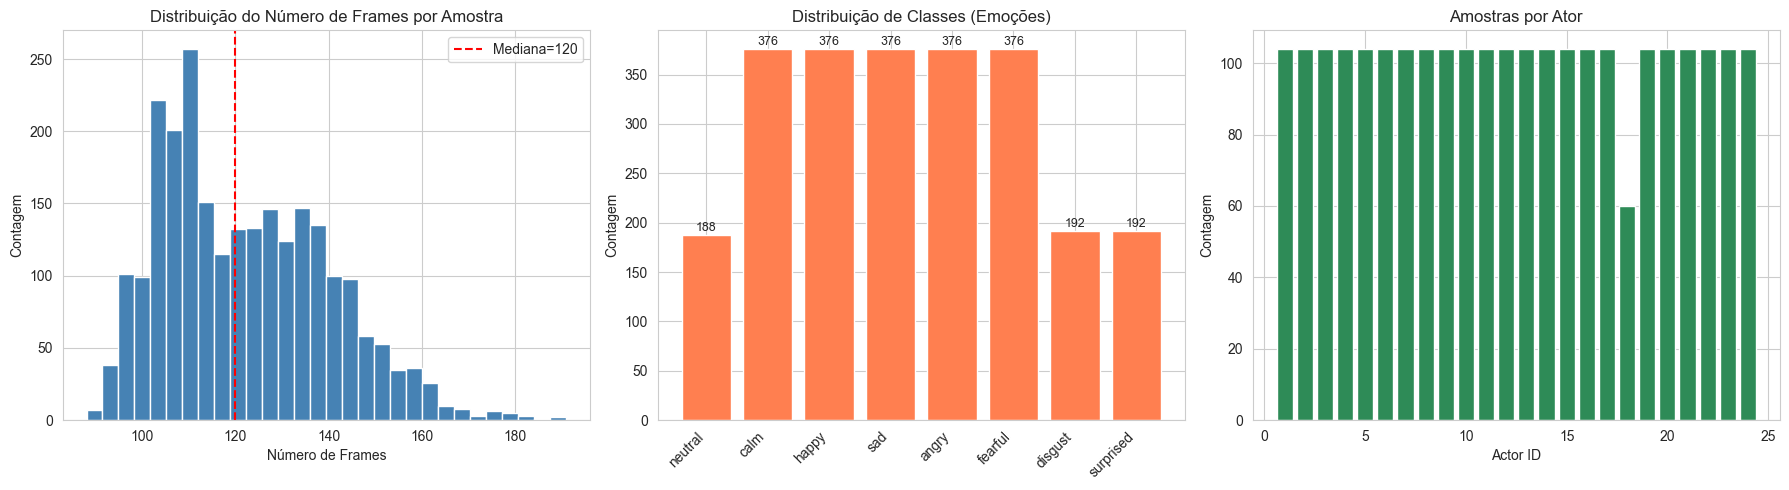

Figura salva em 03_qc/qc_distributions.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Histograma de frames
axes[0].hist(valid['n_frames'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Número de Frames')
axes[0].set_ylabel('Contagem')
axes[0].set_title('Distribuição do Número de Frames por Amostra')
axes[0].axvline(valid['n_frames'].median(), color='red', linestyle='--', label=f"Mediana={valid['n_frames'].median():.0f}")
axes[0].legend()

# 2) Distribuição de classes (emoções)
emotion_order = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP.keys())]
emo_counts = valid['emotion_label'].value_counts().reindex(emotion_order, fill_value=0)
bars = axes[1].bar(range(len(emo_counts)), emo_counts.values, color='coral', edgecolor='white')
axes[1].set_xticks(range(len(emo_counts)))
axes[1].set_xticklabels(emo_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Contagem')
axes[1].set_title('Distribuição de Classes (Emoções)')
# Adicionar valores nas barras
for bar, val in zip(bars, emo_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=9)

# 3) Distribuição por ator
actor_cts = valid['actor_id'].value_counts().sort_index()
axes[2].bar(actor_cts.index, actor_cts.values, color='seagreen', edgecolor='white')
axes[2].set_xlabel('Actor ID')
axes[2].set_ylabel('Contagem')
axes[2].set_title('Amostras por Ator')

plt.tight_layout()
plt.savefig(os.path.join(QC_DIR, 'qc_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em 03_qc/qc_distributions.png")

## 1.8 Tabela Resumo (pronta para copiar no artigo)

In [13]:
# Tabela cruzada: emoção x ator
cross = pd.crosstab(valid['emotion_label'], valid['actor_id'], margins=True)
print("Tabela cruzada: Emoção x Ator")
print("=" * 80)
cross

Tabela cruzada: Emoção x Ator


actor_id,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,All
emotion_label,,,,,,,,,,,,,,,,,,,,,
angry,16,16,16,16,16,16,16,16,16,16,...,16,16,8,16,16,16,16,16,16,376
calm,16,16,16,16,16,16,16,16,16,16,...,16,16,8,16,16,16,16,16,16,376
disgust,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,192
fearful,16,16,16,16,16,16,16,16,16,16,...,16,16,8,16,16,16,16,16,16,376
happy,16,16,16,16,16,16,16,16,16,16,...,16,16,8,16,16,16,16,16,16,376
neutral,8,8,8,8,8,8,8,8,8,8,...,8,8,4,8,8,8,8,8,8,188
sad,16,16,16,16,16,16,16,16,16,16,...,16,16,8,16,16,16,16,16,16,376
surprised,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,192
All,104,104,104,104,104,104,104,104,104,104,...,104,104,60,104,104,104,104,104,104,2452


In [14]:
# Resumo final
print("\n" + "=" * 60)
print("RESUMO DO DATASET (para artigo)")
print("=" * 60)
print(f"Total de amostras:       {len(valid)}")
print(f"Atores:                  {valid['actor_id'].nunique()}")
print(f"Classes de emoção:       {valid['emotion_code'].nunique()}")
print(f"Features por frame:      {valid['n_features'].mode().iloc[0] if len(valid) > 0 else 'N/A'}")
print(f"Frames por amostra:      {valid['n_frames'].min()} - {valid['n_frames'].max()} (média={valid['n_frames'].mean():.1f})")
print(f"Amostras com NaN:        {valid['has_nan'].sum()}")
print("=" * 60)
print("\nNotebook 01 concluído com sucesso!")


RESUMO DO DATASET (para artigo)
Total de amostras:       2452
Atores:                  24
Classes de emoção:       8
Features por frame:      712
Frames por amostra:      88 - 191 (média=122.3)
Amostras com NaN:        0

Notebook 01 concluído com sucesso!
